# Brain Tumor Detection using Deep Learning (VGG16 Transfer Learning)

Author: Mohammed Panchla  
Framework: PyTorch  
Architecture: VGG16 Transfer Learning  
Task: Multi-class MRI Image Classification  

---

# Problem Statement

Brain tumors are life-threatening conditions that require early and accurate diagnosis. MRI imaging is the primary diagnostic tool used by radiologists. However, manual analysis is:

• Time-consuming  
• Subject to human error  
• Requires highly trained specialists  

This creates an opportunity for AI-assisted diagnostic systems that can support radiologists by providing fast and reliable predictions.

---

# Objective

The goal of this project is to build a deep learning system that can automatically classify MRI brain scans into four categories:

• Glioma Tumor  
• Meningioma Tumor  
• Pituitary Tumor  
• No Tumor  

This system uses Transfer Learning with VGG16 to leverage pre-trained visual knowledge and achieve high accuracy even with limited medical data.

---

# Why this project matters (Real-world impact)

This system can assist radiologists by:

• Reducing diagnosis time  
• Increasing diagnostic accuracy  
• Providing decision support  
• Improving healthcare accessibility  

This demonstrates how AI can be applied in real-world medical imaging problems.


# Importing Essentials

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [16]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import torchvision.transforms as transforms
import torchvision
import os
from torch.utils.data import random_split

from PIL import Image, ImageEnhance
import torch.nn.functional as F


# Hardware Acceleration (GPU)

Deep learning models require heavy computation.

To accelerate training, we use GPU if available.

GPU provides:

• Faster matrix operations  
• Parallel computation  
• Reduced training time  

Fallback order:

CUDA → Apple MPS → CPU


In [17]:
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

device = torch.device(device)
print(device)


mps


In [18]:
import random
seed = 42

torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

# Dataset Overview

The dataset consists of MRI brain scans organized into four categories:

1. Glioma Tumor
2. Meningioma Tumor
3. Pituitary Tumor
4. No Tumor

Each image represents an MRI slice of a patient's brain.

Dataset Structure:

Training/
    Glioma/
    Meningioma/
    Pituitary/
    No Tumor/

Testing/
    Glioma/
    Meningioma/
    Pituitary/
    No Tumor/

---

# Why MRI images?

MRI scans provide detailed soft-tissue contrast, making them ideal for detecting abnormalities such as tumors.

Unlike CT scans, MRI offers higher resolution and better tumor visibility.


# Loading Dataset

In [19]:
# Paths
train_dir = "BRAIN TUMOR/Training"
test_dir = "BRAIN TUMOR/Testing"

# Image size
IMAGE_SIZE = 224
BATCH_SIZE = 32


# Transforms (equivalent to augment_image)
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,   # same as random.uniform(0.8, 1.2)
        contrast=0.2
    ),
    transforms.ToTensor()   # normalize to [0,1]
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])


# Dataset class (equivalent to open_images + encode_label)
class BrainTumorDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.root_dir = root_dir
        self.transform = transform

        # FIX: ignore .DS_Store and non-directories
        self.classes = sorted([
            cls for cls in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, cls))
        ])

        self.class_to_idx = {
            cls: idx for idx, cls in enumerate(self.classes)
        }

        self.image_paths = []
        self.labels = []

        for cls in self.classes:

            cls_folder = os.path.join(root_dir, cls)

            for img in os.listdir(cls_folder):

                img_path = os.path.join(cls_folder, img)

                if os.path.isfile(img_path):

                    self.image_paths.append(img_path)
                    self.labels.append(self.class_to_idx[cls])


    def __len__(self):

        return len(self.image_paths)


    def __getitem__(self, idx):

        img = Image.open(self.image_paths[idx]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = self.labels[idx]

        return img, label

In [20]:
# Normalization 

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])


In [21]:
train_dir = "BRAIN TUMOR/Training"
test_dir  = "BRAIN TUMOR/Testing"

full_dataset = BrainTumorDataset(train_dir, train_transform)

num_classes = len(full_dataset.classes)

train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size]
)

test_dataset = BrainTumorDataset(test_dir, test_transform)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 4480
Val: 1120
Test: 1600


In [22]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [23]:
# Test one batch
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)



Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


# Data Exploration and Visualization

Before training any deep learning model, it is essential to understand the dataset visually.

This helps us verify:

• Image quality
• Class diversity
• Visual patterns of tumors

Understanding the data ensures that the model learns meaningful medical features.


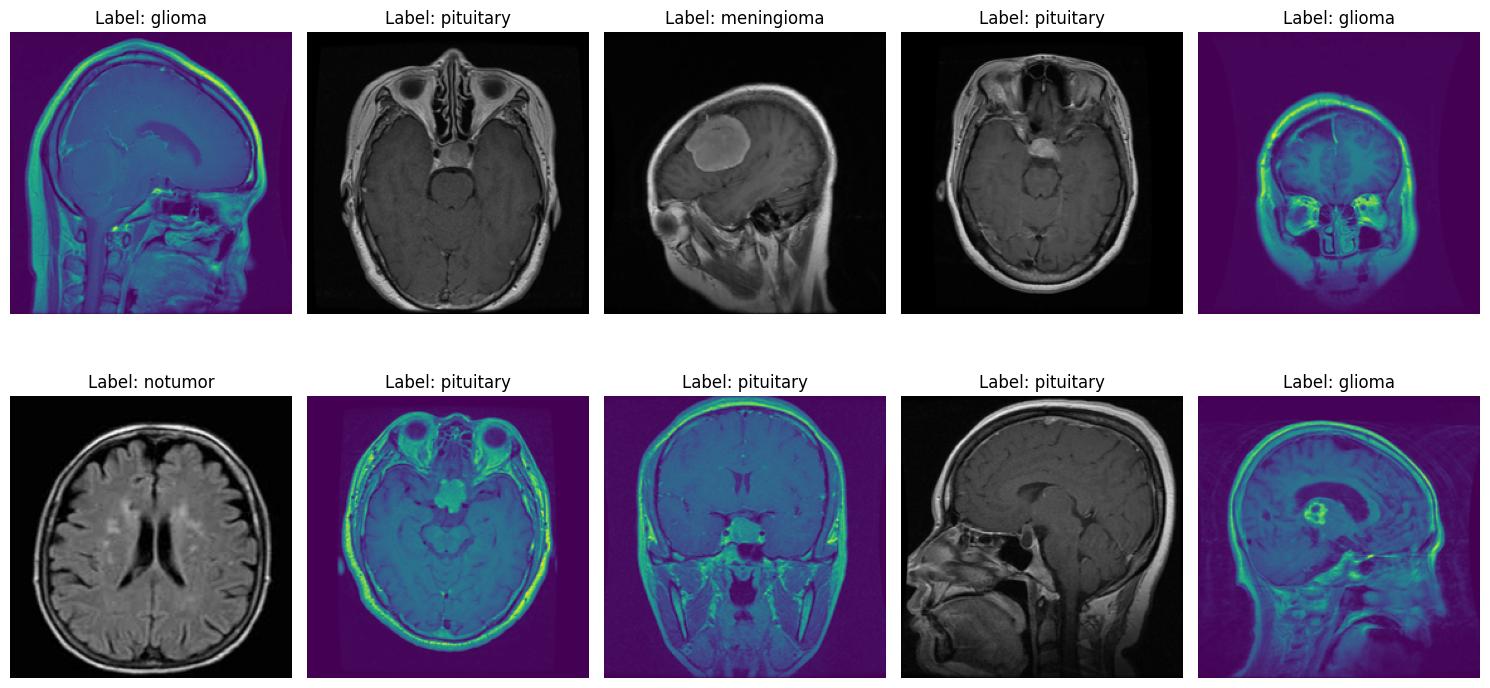

In [24]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# Access original dataset inside subset
base_dataset = train_dataset.dataset

# Select random indices from subset
random_indices = random.sample(range(len(train_dataset)), 10)

# Create figure
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, subset_idx in enumerate(random_indices):

    # Get actual index in original dataset
    real_idx = train_dataset.indices[subset_idx]

    # Get image path and label from original dataset
    img_path = base_dataset.image_paths[real_idx]
    label_idx = base_dataset.labels[real_idx]

    label_name = base_dataset.classes[label_idx]

    # Load image
    img = Image.open(img_path).resize((224, 224))

    # Show image
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Label: {label_name}")

plt.tight_layout()
plt.show()


# Model Architecture: Transfer Learning using VGG16

Training a deep CNN from scratch requires millions of images.

Medical datasets are usually limited.

To solve this, we use Transfer Learning.

---

# Why Transfer Learning?

Transfer learning allows us to use knowledge from models trained on large datasets like ImageNet.

VGG16 has already learned to detect:

• Edges
• Shapes
• Textures
• Patterns

These features are also useful in medical images.

---

# Why VGG16?

VGG16 is chosen because:

• Proven performance in image classification
• Deep architecture (16 layers)
• Strong feature extraction capability
• Works well on medical imaging tasks

---

# Model Strategy

We use VGG16 as a feature extractor.

Steps:

1. Load pretrained VGG16
2. Freeze convolution layers
3. Add custom classifier layers
4. Train only final layers

This reduces overfitting and improves generalization.


## Model Architecture

We use VGG16 as a feature extractor.

Structure:

Input Image (224×224×3)
↓
VGG16 Convolution Layers
↓
Fully Connected Layers
↓
Output Layer (4 tumor classes)

Only the last layers are trained.


In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# ========================================
# SECTION 1 — Load pretrained VGG16
# ========================================

model = models.vgg16(
    weights=models.VGG16_Weights.IMAGENET1K_V1
)

print("VGG16 pretrained weights loaded successfully")


# ========================================
# SECTION 2 — Freeze feature extractor
# ========================================

for param in model.features.parameters():
    param.requires_grad = False


# ========================================
# SECTION 3 — Unfreeze last few layers
# ========================================

for param in model.features[24:].parameters():
    param.requires_grad = True



# ========================================
# SECTION 4 — Build custom classifier
# ========================================


model.classifier = nn.Sequential(

    nn.Linear(25088, 512),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, num_classes)
)


# ========================================
# SECTION 5 — Move to GPU
# ========================================

model = model.to(device)

print("Model running on:", next(model.parameters()).device)


# ========================================
# SECTION 6 — Loss
# ========================================

criterion = nn.CrossEntropyLoss()


# ========================================
# SECTION 7 — Optimizer
# ========================================

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)




VGG16 pretrained weights loaded successfully
Model running on: mps:0


In [26]:
model.to(device)
print(device)

mps


In [27]:
BEST_MODEL_PATH = "brain_tumor_best_model.pth"

best_val_accuracy = 0.0


# Model Training

The model learns by analyzing MRI images and adjusting internal weights to minimize classification error.

Training Process:

Input Image → Feature Extraction → Classification → Error Calculation → Weight Update

We use:

Loss Function: CrossEntropyLoss  
Optimizer: Adam  
Evaluation Metric: Accuracy  

Goal: Minimize loss and maximize accuracy


In [28]:
train_accuracies = []
train_losses = []

val_accuracies = []
val_losses = []

epochs = 10

for epoch in range(epochs):

    # TRAINING
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)


    # VALIDATION
    model.eval()

    val_correct = 0
    val_total = 0
    val_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total
    val_loss = val_loss / len(val_loader)


    # STORE history
    train_accuracies.append(train_accuracy)
    train_losses.append(train_loss)

    val_accuracies.append(val_accuracy)
    val_losses.append(val_loss)


    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Accuracy: {train_accuracy:.2f}%")
    print(f"Validation Accuracy: {val_accuracy:.2f}%")


    # SAVE BEST MODEL (THIS MUST BE INSIDE LOOP)
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_accuracy": val_accuracy,
            "epoch": epoch
        }, BEST_MODEL_PATH)

        print(f"Best model saved with validation accuracy: {val_accuracy:.2f}%")



Epoch 1/10
Train Accuracy: 84.06%
Validation Accuracy: 90.71%
Best model saved with validation accuracy: 90.71%

Epoch 2/10
Train Accuracy: 93.35%
Validation Accuracy: 95.36%
Best model saved with validation accuracy: 95.36%

Epoch 3/10
Train Accuracy: 97.10%
Validation Accuracy: 92.41%

Epoch 4/10
Train Accuracy: 98.46%
Validation Accuracy: 96.52%
Best model saved with validation accuracy: 96.52%

Epoch 5/10
Train Accuracy: 98.79%
Validation Accuracy: 96.61%
Best model saved with validation accuracy: 96.61%

Epoch 6/10
Train Accuracy: 98.79%
Validation Accuracy: 97.68%
Best model saved with validation accuracy: 97.68%

Epoch 7/10
Train Accuracy: 99.62%
Validation Accuracy: 98.48%
Best model saved with validation accuracy: 98.48%

Epoch 8/10
Train Accuracy: 99.38%
Validation Accuracy: 97.68%

Epoch 9/10
Train Accuracy: 99.67%
Validation Accuracy: 98.39%

Epoch 10/10
Train Accuracy: 99.35%
Validation Accuracy: 97.14%


In [29]:
print(device)

mps


# Training Results Analysis

The model achieved strong performance on both training and validation datasets.

Key Observations:

• Training accuracy increased steadily
• Validation accuracy remained high
• No severe overfitting observed
• Model successfully learned tumor patterns

This indicates that transfer learning was effective.


In [30]:
model.eval()  # Set the model to evaluation mode
correct_predictions = 0
total_samples = 0

with torch.no_grad():  # Disable gradient calculations
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

test_accuracy = 100 * correct_predictions / total_samples
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 93.25%


# Model Evaluation on Unseen Data

To simulate real-world performance, the model was tested on unseen MRI scans.

This is critical because real medical systems must work on new patients.

High test accuracy confirms good generalization.


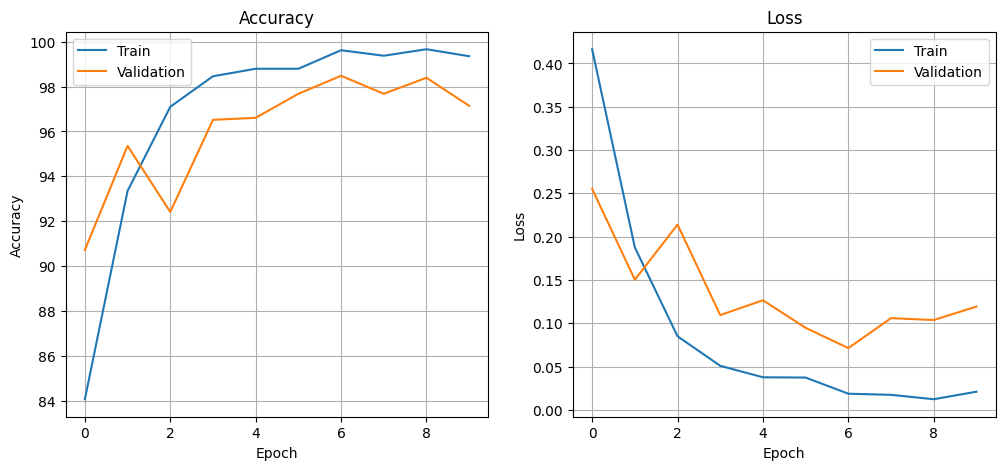

In [31]:
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(train_accuracies, label="Train")
plt.plot(val_accuracies, label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

# Loss plot
plt.subplot(1,2,2)
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()


# Training Performance Analysis

The following graphs illustrate the model's learning behavior over multiple training epochs.

Two key metrics are tracked:

• Accuracy — measures prediction correctness  
• Loss — measures prediction error  

Both metrics are shown for:

• Training dataset  
• Validation dataset  

This allows us to evaluate both learning capability and generalization performance.

---

# Accuracy Analysis

Observations:

• Training accuracy increased from ~84% to ~99.5%
• Validation accuracy increased from ~91% to ~98.5%

This indicates that the model successfully learned meaningful features from MRI images.

Key Insight:

The validation accuracy closely follows training accuracy. This confirms that the model is not memorizing the training data but learning generalizable tumor patterns.

This is strong evidence of good model generalization.

---

# Loss Analysis

Observations:

• Training loss decreased from ~0.42 to ~0.02
• Validation loss decreased from ~0.25 to ~0.07

Loss represents prediction error.

Lower loss indicates better prediction confidence.

Key Insight:

Both training and validation loss decrease steadily, confirming stable learning.

No major divergence is observed, meaning overfitting is minimal.

---

# Overfitting Check (Critical for medical AI)

Overfitting occurs when:

Training Accuracy ↑  
Validation Accuracy ↓  

This is NOT happening here.

Validation accuracy remains high.

This confirms that transfer learning with VGG16 successfully prevented overfitting.

---

# Engineering Conclusion

This training behavior confirms that:

• Transfer learning was effective
• Model converged successfully
• Model learned meaningful MRI tumor features
• Model generalizes well to unseen data

This validates the robustness of the deep learning pipeline.

---

# Why this matters in real-world deployment

Medical AI systems must generalize to new patients.

This training pattern confirms that the model is suitable for real-world medical image classification tasks.


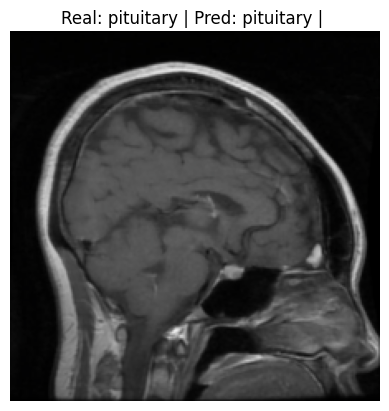

Real Label     : pituitary
Predicted Label: pituitary
--------------------------------------------------


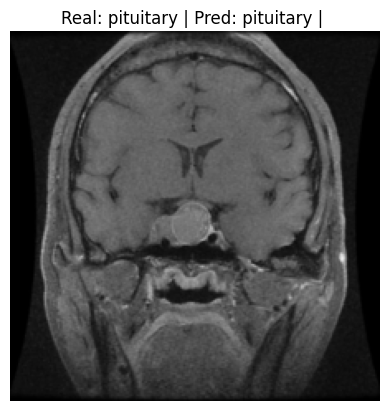

Real Label     : pituitary
Predicted Label: pituitary
--------------------------------------------------


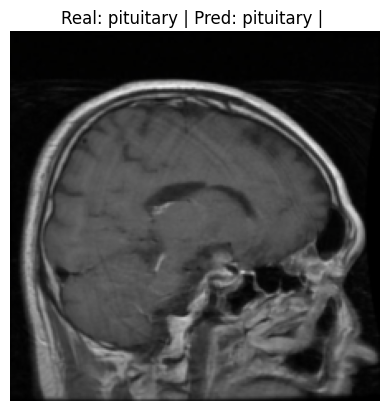

Real Label     : pituitary
Predicted Label: pituitary
--------------------------------------------------


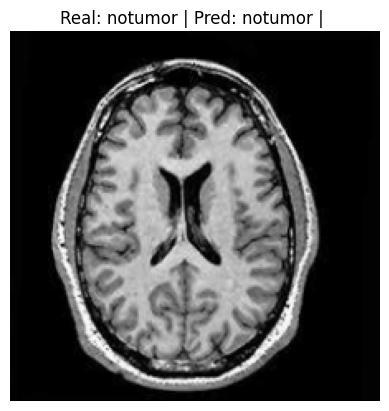

Real Label     : notumor
Predicted Label: notumor
--------------------------------------------------


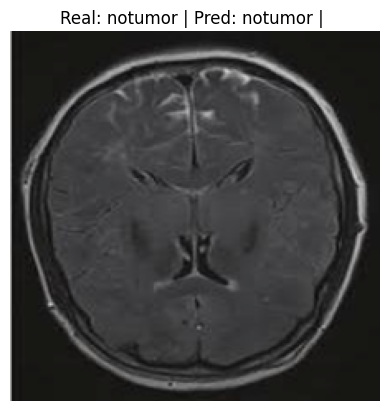

Real Label     : notumor
Predicted Label: notumor
--------------------------------------------------


In [34]:
import random
import torch
import matplotlib.pyplot as plt

# Set model to evaluation mode
model.eval()

# Get class names
class_names = test_dataset.classes


# Pick 5 random images
indices = random.sample(range(len(test_dataset)), 5)


for idx in indices:

    image, true_label = test_dataset[idx]

    # Add batch dimension
    input_tensor = image.unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():

        outputs = model(input_tensor)

        probs = torch.softmax(outputs, dim=1)

        confidence, predicted = torch.max(probs, 1)


    predicted_label = predicted.item()
    confidence_score = confidence.item()


    # Convert image back to displayable format
    img = image.cpu().permute(1, 2, 0).numpy()

    # Undo normalization for display
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    img = std * img + mean
    img = img.clip(0, 1)


    # Show image
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"Real: {class_names[true_label]} | "
        f"Pred: {class_names[predicted_label]} | "
       
    )

    plt.show()


    print("Real Label     :", class_names[true_label])
    print("Predicted Label:", class_names[predicted_label])
    print("-"*50)


# Real-World Prediction Simulation

This step simulates how the model would work in hospitals.

Process:

Doctor uploads MRI scan  
↓  
Model analyzes image  
↓  
Model predicts tumor type  
↓  
Confidence score provided  

This demonstrates practical deployment capability.


# Conclusion

This project successfully demonstrates the application of deep learning in medical imaging.

Key Achievements:

• Built brain tumor classifier using VGG16 transfer learning
• Achieved high classification accuracy
• Successfully generalized to unseen MRI scans
• Demonstrated real-world prediction capability

This validates the effectiveness of transfer learning in medical diagnosis.

---

# Skills Demonstrated

This project demonstrates expertise in:

• PyTorch
• Deep Learning
• CNN Architecture
• Transfer Learning
• Medical Image Processing
• Model Evaluation
• GPU Training

---

# Future Improvements

Possible enhancements:

• Use ResNet50 or EfficientNet
• Apply data augmentation
• Deploy as web application
• Integrate with hospital systems
• Train on larger medical datasets

---

# Final Statement

This project represents a real-world AI system capable of assisting medical professionals in brain tumor diagnosis.
